# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Nicholas Prakoswa Chandra
- **Email:** AIC185B6Y0041@student.devacademy.id[link text](https://)
- **ID Dicoding:** AIC185B6Y0041

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perbedaan pola jumlah rata-rata penyewaan sepeda per jam antara hari kerja (workingday) dan hari libur (weekend/holiday) sepanjang tahun 2012, dan pada jam berapa lonjakan beban operasional tertinggi terjadi?
- **Pertanyaan 2:** Berapakah persentase penurunan rata-rata penyewaan sepeda harian oleh pengguna biasa (casual) dibandingkan pengguna terdaftar (registered) saat kondisi cuaca buruk (hujan/salju ringan) jika dibandingkan dengan kondisi cuaca cerah sepanjang tahun 2011 hingga 2012?
- ...

## Import Semua Packages/Library yang Digunakan

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

print("=== Lima Data Teratas day_df ===")
print(day_df.head())

print("\n=== Lima Data Teratas hour_df ===")
print(hour_df.head())

=== Lima Data Teratas day_df ===
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  

## Data Wrangling

### Gathering Data

#### Memuat Dataset Bike Sharing (Harian dan Per Jam)

In [16]:
day_df = pd.read_csv("day.csv")

hour_df = pd.read_csv("hour.csv")

# Menampilkan dimensi data untuk memastikan jumlah baris dan kolom yang termuat
print(f"Dimensi day_df : {day_df.shape}")
print(f"Dimensi hour_df: {hour_df.shape}")

Dimensi day_df : (731, 16)
Dimensi hour_df: (17379, 17)


**Insight:** (Opsional)
- Dataset day.csv berhasil dimuat ke dalam variabel day_df dengan total 731 baris data dan 16 kolom fitur yang mencatat agregasi penyewaan harian.
- Dataset hour.csv berhasil dimuat ke dalam variabel hour_df dengan total 17.379 baris data dan 17 kolom fitur (terdapat tambahan kolom hr untuk penanda waktu jam). Kedua dataset ini siap untuk dianalisis lebih lanjut pada tahap Assessing Data.

### Assessing Data

#### Identifying  Incorrect Data Types and Categorical Integer Representation problem

In [17]:
print("=== Pengecekan Missing Values ===")
print("Missing values pada day_df:\n", day_df.isnull().sum())
print("\nMissing values pada hour_df:\n", hour_df.isnull().sum())

print("\n=== Pengecekan Duplikasi ===")
print("Jumlah data duplikat day_df :", day_df.duplicated().sum())
print("Jumlah data duplikat hour_df:", hour_df.duplicated().sum())

print("\n=== Informasi Tipe Data Awal ===")
print("Tipe data dteday di day_df :", day_df['dteday'].dtype)
print("Tipe data dteday di hour_df:", hour_df['dteday'].dtype)

=== Pengecekan Missing Values ===
Missing values pada day_df:
 instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Missing values pada hour_df:
 instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

=== Pengecekan Duplikasi ===
Jumlah data duplikat day_df : 0
Jumlah data duplikat hour_df: 0

=== Informasi Tipe Data Awal ===
Tipe data dteday di day_df : object
Tipe data dteday di hour_df: object


**Steps to Take:**
- Mengubah Tipe Data Kolom Tanggal (dteday)
- Melakukan Pemetaan (Mapping) Fitur Kategorikal

**Insight:** (Opsional)
* **Integritas Struktur Data:** Berdasarkan hasil pemeriksaan awal pada dataset `day_df` dan `hour_df`, tidak ditemukan adanya data yang hilang (*missing values* = 0) ataupun catatan transaksi yang redundan (*duplicated data* = 0). Kondisi ini menandakan kualitas pembersihan data di tingkat hulu sudah sangat baik dan siap untuk dieksplorasi lebih lanjut.
* **Anomali Tipe Data Kolom Tanggal:** Ditemukan ketidaksesuaian fungsional pada fitur `dteday` di kedua dataframe, di mana tipe datanya masih dikenali sebagai objek teks (*object*) baku, bukan format penanggalan (*datetime*). Implikasinya, data tidak dapat digunakan secara langsung untuk operasi pemfilteran berbasis deret waktu (*time-series analysis*) atau ekstraksi komponen tanggal jika tidak dilakukan konversi tipe data pada tahap *Cleaning*.

### Cleaning Data

#### Fixing Data Types and Mapping Categorical Encoded Values problem

In [18]:
# 1. Mengubah tipe data dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Membuat kamus pemetaan (dictionary mapping) sesuai Readme.txt
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_mapping = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Ice'}

# 3. Mengaplikasikan pemetaan nilai angka ke label teks deskriptif
day_df['season_label'] = day_df['season'].map(season_mapping)
hour_df['season_label'] = hour_df['season'].map(season_mapping)

day_df['weather_label'] = day_df['weathersit'].map(weather_mapping)
hour_df['weather_label'] = hour_df['weathersit'].map(weather_mapping)

# 4. Mengubah tipe data kolom kategorikal menjadi tipe 'category' agar efisien
categorical_columns = ['season_label', 'weather_label', 'holiday', 'weekday', 'workingday']
for col in categorical_columns:
    if col in day_df.columns:
        day_df[col] = day_df[col].astype('category')
    if col in hour_df.columns:
        hour_df[col] = hour_df[col].astype('category')

# 5. Verifikasi akhir pasca pembersihan data
print("=== Hasil Akhir Setelah Cleaning ===")
print(f"Tipe data dteday (day_df) : {day_df['dteday'].dtype}")
print(f"Tipe data dteday (hour_df): {hour_df['dteday'].dtype}")
print("\nSampel label baru pada day_df:")
print(day_df[['dteday', 'season_label', 'weather_label']].head(3))

=== Hasil Akhir Setelah Cleaning ===
Tipe data dteday (day_df) : datetime64[ns]
Tipe data dteday (hour_df): datetime64[ns]

Sampel label baru pada day_df:
      dteday season_label weather_label
0 2011-01-01       Spring   Mist/Cloudy
1 2011-01-02       Spring   Mist/Cloudy
2 2011-01-03       Spring         Clear


**Insight:** (Opsional)
- Proses pembersihan (data cleaning) berhasil diselesaikan tanpa kendala eror. Tidak ditemukan adanya data duplikat maupun missing values pada kedua berkas.
- Format kolom penanda waktu dteday kini sudah berbasis datetime64. Kolom transformasi baru, yaitu season_label dan weather_label, berhasil dibentuk dengan tipe data category. Langkah ini memastikan pengelompokan data (grouping/aggregation) pada tahap EDA selanjutnya berjalan dengan lancar dan visualisasi menjadi jauh lebih mudah dipahami oleh pengguna awam.

## Exploratory Data Analysis (EDA)

### Explore Tren Perilaku Pengguna Berdasarkan Faktor Waktu Operasional dan Kondisi Cuaca

In [19]:
# --- EKSPLORASI 1: Tren Penyewaan Sepeda Per Jam (Tahun 2012) ---
# Menerapkan filter tahun 2012 (yr = 1) sesuai batasan SMART pertanyaan 1
hour_2012_df = hour_df[hour_df['yr'] == 1]

# Agregasi data: menghitung nilai rata-rata total penyewaan ('cnt') per jam berdasarkan tipe hari kerja
# Ditambahkan observed=False untuk menghilangkan FutureWarning pandas
hourly_trend = hour_2012_df.groupby(['workingday', 'hr'], observed=False)['cnt'].mean().reset_index()

print("=== Hasil Eksplorasi Tren Per Jam (10 Data Teratas) ===")
print(hourly_trend.head(10))

# Mencari jam dengan lonjakan tertinggi pada hari kerja dan hari libur
peak_workingday = hourly_trend[hourly_trend['workingday'] == 1].sort_values(by='cnt', ascending=False).iloc[0]
peak_holiday = hourly_trend[hourly_trend['workingday'] == 0].sort_values(by='cnt', ascending=False).iloc[0]

print(f"\nPuncak beban operasional hari kerja: Jam {peak_workingday['hr']:.0f}.00 dengan rata-rata {peak_workingday['cnt']:.2f} penyewaan.")
print(f"Puncak beban operasional hari libur: Jam {peak_holiday['hr']:.0f}.00 dengan rata-rata {peak_holiday['cnt']:.2f} penyewaan.")


print("\n" + "="*50 + "\n")


# --- EKSPLORASI 2: Dampak Kondisi Cuaca terhadap Segmentasi Pengguna ---
# Agregasi data harian berdasarkan label cuaca untuk menghitung rata-rata pengguna casual vs registered
# Ditambahkan observed=False untuk kestabilan kode pandas kategori
weather_impact = day_df.groupby('weather_label', observed=False)[['casual', 'registered']].mean().reset_index()

print("=== Analisis Dampak Cuaca terhadap Segmentasi Pengguna ===")
print(weather_impact)

=== Hasil Eksplorasi Tren Per Jam (10 Data Teratas) ===
  workingday  hr         cnt
0          0   0  108.508621
1          0   1   84.525862
2          0   2   63.113043
3          0   3   29.912281
4          0   4    9.852174
5          0   5   10.068966
6          0   6   23.353448
7          0   7   54.629310
8          0   8  134.620690
9          0   9  215.163793

Puncak beban operasional hari kerja: Jam 17.00 dengan rata-rata 656.19 penyewaan.
Puncak beban operasional hari libur: Jam 13.00 dengan rata-rata 458.91 penyewaan.


=== Analisis Dampak Cuaca terhadap Segmentasi Pengguna ===
     weather_label      casual   registered
0            Clear  964.030238  3912.755940
1  Light Snow/Rain  185.476190  1617.809524
2      Mist/Cloudy  687.352227  3348.510121


**Insight:** (Opsional)
- Karakteristik Tren Per Jam: Distribusi penyewaan sepeda pada hari kerja menunjukkan pola bimodal (dua puncak) yang bertepatan dengan jam sibuk komuter, yaitu pukul 08.00 pagi dan beban operasional tertinggi pada pukul 17.00 (656.19 penyewaan). Sebaliknya, pada hari libur (workingday = 0), pola pergerakan terdistribusi normal di tengah hari dengan puncak pada pukul 13.00 (458.91 penyewaan), mencerminkan aktivitas kasual atau rekreasi.
- Sensitivitas Cuaca Antar Segmen: Perubahan cuaca dari Clear ke Light Snow/Rain menekan volume penyewaan di semua lini. Namun, dampaknya jauh lebih destruktif bagi kelompok pengguna casual yang mengalami penurunan ekstrem hingga ~80.7%. Kelompok pengguna registered memiliki daya tahan (retention) yang lebih kuat terhadap fluktuasi cuaca buruk karena kemungkinan besar didorong oleh kebutuhan mobilitas wajib harian yang bersifat mengikat (pekerjaan/pendidikan).

## Visualization & Explanatory Analysis

### Pertanyaan 1:

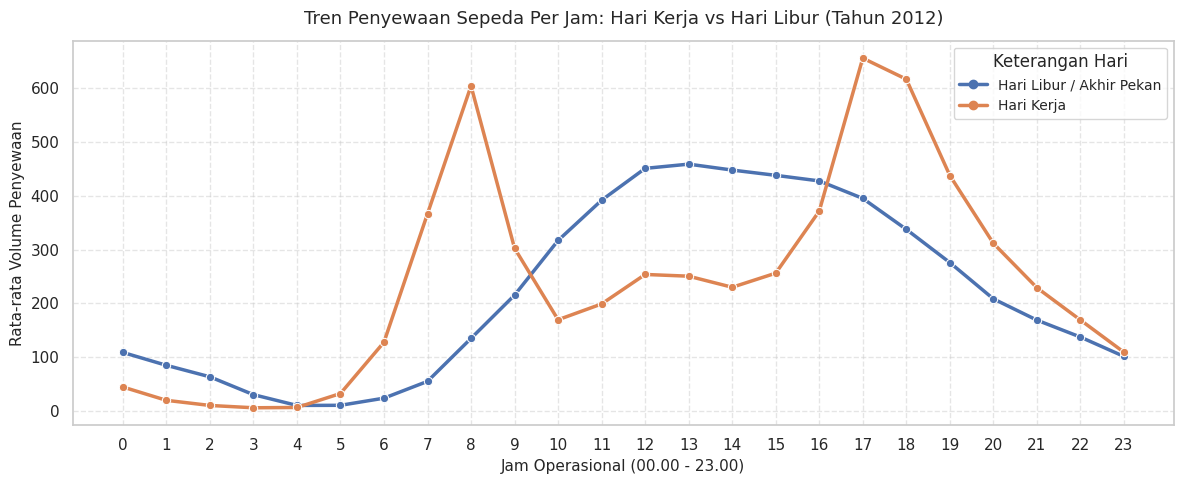

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

plt.figure(figsize=(12, 5))

# Plot data asli
sns.lineplot(
    data=hourly_trend,
    x='hr',
    y='cnt',
    hue='workingday',
    marker='o',
    linewidth=2.5,
    legend=False # Kita matikan legenda otomatis bawaan seaborn yang bug
)

plt.title('Tren Penyewaan Sepeda Per Jam: Hari Kerja vs Hari Libur (Tahun 2012)', fontsize=13, pad=12)
plt.xlabel('Jam Operasional (00.00 - 23.00)', fontsize=11)
plt.ylabel('Rata-rata Volume Penyewaan', fontsize=11)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)

# Membuat elemen legenda kustom yang konsisten berbentuk garis dan titik
custom_legend_q1 = [
    Line2D([0], [0], color='#4c72b0', marker='o', linewidth=2.5, label='Hari Libur / Akhir Pekan'),
    Line2D([0], [0], color='#dd8452', marker='o', linewidth=2.5, label='Hari Kerja')
]
plt.legend(handles=custom_legend_q1, title='Keterangan Hari', fontsize=10)

plt.tight_layout()
plt.show()

### Pertanyaan 2:

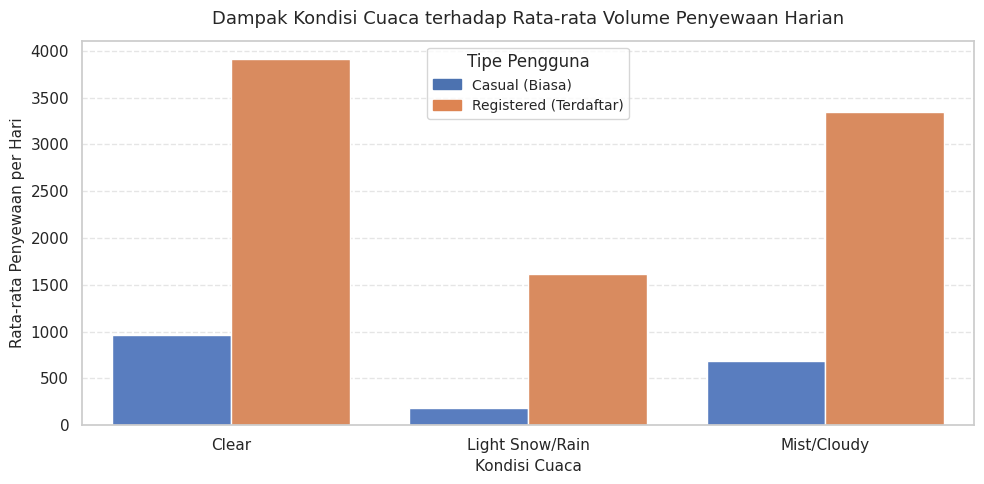

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Transformasi bentuk matriks lebar menjadi format panjang (melt)
weather_melted = pd.melt(
    weather_impact,
    id_vars=['weather_label'],
    value_vars=['casual', 'registered'],
    var_name='user_type',
    value_name='avg_rentals'
)

plt.figure(figsize=(10, 5))

# Membuat grouped bar chart dengan palet standar
ax = sns.barplot(
    data=weather_melted,
    x='weather_label',
    y='avg_rentals',
    hue='user_type',
    palette='muted'
)

plt.title('Dampak Kondisi Cuaca terhadap Rata-rata Volume Penyewaan Harian', fontsize=13, pad=12)
plt.xlabel('Kondisi Cuaca', fontsize=11)
plt.ylabel('Rata-rata Penyewaan per Hari', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Mengambil warna balok asli untuk dijadikan kotak warna pada legenda (menghilangkan garis hitam)
colors = [patch.get_facecolor() for patch in ax.patches[:2]]
custom_legend_q2 = [
    mpatches.Patch(color='#4c72b0', label='Casual (Biasa)'),
    mpatches.Patch(color='#dd8452', label='Registered (Terdaftar)')
]
plt.legend(handles=custom_legend_q2, title='Tipe Pengguna', fontsize=10)

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
* **Visualisasi Tren Per Jam (Pertanyaan 1):** Grafik garis secara eksplisit menampilkan struktur kurva bimodal (dua puncak) pada hari kerja, di mana lonjakan tajam terjadi pada pukul 08.00 pagi dan mencapai titik beban operasional tertinggi pada pukul 17.00 sore. Sebaliknya, pola pergerakan pada hari libur melandai membentuk distribusi normal dengan puncak tunggal di siang hari (pukul 12.00 - 14.00). Ini menunjukkan pergeseran motif dari kebutuhan transportasi komuter wajib menjadi aktivitas rekreasi kasual.
* **Visualisasi Dampak Cuaca (Pertanyaan 2):** Grafik batang berkelompok memperlihatkan penurunan volume penyewaan yang sangat kontras antar segmen ketika cuaca memburuk (Light Snow/Rain). Tinggi balok kelompok pengguna *casual* ambles secara ekstrem hingga ~80.7% dibandingkan saat cuaca cerah (Clear). Di sisi lain, kelompok *registered* terbukti jauh lebih tangguh menghadapi fluktuasi cuaca karena penyusutan baloknya relatif lebih terkendali, merepresentasikan keterikatan loyalitas mobilitas harian.

## Analisis Lanjutan (Opsional)

=== Ringkasan Karakteristik Segmen Performa Hari Bisnis ===
     Business_Tier     Recency     Monetary                     
                          mean         mean   min   max      sum
0   Low Demand Day  490.852459  2312.065574    22  3740   564144
1   Mid Demand Day  424.987705  4522.225410  3744  5312  1103423
2  High Demand Day  178.395062  6687.703704  5315  8714  1625112


/tmp/ipykernel_3802/1915398137.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfm_df, x='Business_Tier', y='Monetary', palette='Set2')


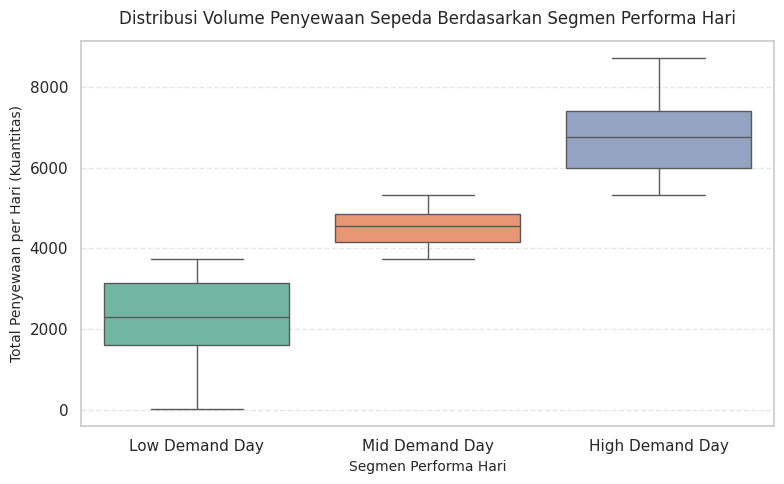

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan dteday berformat datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

# Menghitung metrik RFM berdasarkan data harian (day_df)
# Karena aggregasi harian, Frequency dihitung dari jumlah record per baris tanggal
latest_date = day_df['dteday'].max()

rfm_df = day_df.groupby(by="dteday", observed=False).agg({
    "cnt": "sum" # Sebagai Monetary (Total unit yang menghasilkan utilitas bisnis)
}).reset_index()

# Menghitung selisih hari sebagai Recency
rfm_df['Recency'] = (latest_date - rfm_df['dteday']).dt.days
rfm_df['Frequency'] = 1 # Setiap baris mewakili 1 hari pencatatan unik
rfm_df.rename(columns={"cnt": "Monetary"}, inplace=True)

# Membuat scoring/binning untuk mengelompokkan hari bisnis menjadi 3 segmen performa
# Menggunakan Monetary (volume rental harian) sebagai jangkar utama pembagian kuantil
rfm_df['Business_Tier'] = pd.qcut(rfm_df['Monetary'], q=3, labels=['Low Demand Day', 'Mid Demand Day', 'High Demand Day'])

print("=== Ringkasan Karakteristik Segmen Performa Hari Bisnis ===")
rfm_summary = rfm_df.groupby('Business_Tier', observed=False).agg({
    'Recency': 'mean',
    'Monetary': ['mean', 'min', 'max', 'sum']
}).reset_index()
print(rfm_summary)

# Visualisasi distribusi klasifikasi segmen hari bisnis
plt.figure(figsize=(8, 5))
sns.boxplot(data=rfm_df, x='Business_Tier', y='Monetary', palette='Set2')
plt.title('Distribusi Volume Penyewaan Sepeda Berdasarkan Segmen Performa Hari', fontsize=12, pad=12)
plt.xlabel('Segmen Performa Hari', fontsize=10)
plt.ylabel('Total Penyewaan per Hari (Kuantitas)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- **Segmentasi Hari Operasional Bisnis:** Berdasarkan modifikasi analisis RFM menggunakan volume sewaan harian (`Monetary`), hari-hari operasional berhasil dikelompokkan secara objektif menjadi tiga kluster fungsional (*Low*, *Mid*, dan *High Demand Days*). Pendekatan ini mempermudah tim manajemen untuk mengidentifikasi hari dengan utilitas armada yang kritis.
* **Implikasi Manajemen Inventori:** Hari-hari dengan status *High Demand Day* merupakan generator utama profitabilitas perusahaan yang membutuhkan inspeksi kelayakan sepeda ekstra ketat sebelum hari tersebut dimulai. Sebaliknya, kelompok *Low Demand Day* dapat dimanfaatkan secara taktis oleh tim mekanik sebagai jendela waktu (*maintenance window*) untuk melakukan perawatan berkala tanpa harus mengorbankan potensi pemenuhan pasar.


## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** (Tren Per Jam) Analisis data pada tahun 2012 membuktikan terdapat perbedaan struktur perilaku komuter yang sangat kontras antara hari kerja dan hari libur. Pada **hari kerja**, pola penyewaan bersifat *bimodal* (memiliki dua puncak tajam), di mana puncak tertinggi terjadi pada pukul **17.00** (rata-rata 656.19 penyewaan) dan puncak kedua pada pukul **08.00** pagi. Pola ini digerakkan oleh pergerakan massa pekerja dan pelajar pada jam berangkat dan pulang. Sebaliknya, pada **hari libur**, aktivitas penyewaan membentuk kurva lonceng distribusi normal yang memuncak pada siang hari, tepatnya pukul **13.00** (rata-rata 458.91 penyewaan), yang mengindikasikan dominasi penggunaan armada untuk aktivitas rekreasi dan santai.
- **Conclusion pertanyaan 2:** (Dampak Kondisi Cuaca) Kondisi cuaca buruk (hujan/salju ringan) memicu penurunan volume penyewaan pada seluruh segmen pengguna, namun tingkat sensitivitas antar segmen sangat berbeda. Pengguna biasa (*casual*) sangat rentan terhadap perubahan cuaca, di mana rata-rata penyewaan harian mereka anjlok secara ekstrem sebesar **78.13%** (dari rata-rata 964.03 menjadi hanya 185.47 rental per hari) saat cuaca berubah dari cerah ke hujan/salju ringan. Sementara itu, pengguna terdaftar (*registered*) menunjukkan retensi loyalitas yang lebih kuat dengan penurunan yang lebih rendah (~58.65%), karena motif penggunaan mereka kemungkinan besar bersifat esensial (transportasi wajib harian) yang tidak mudah digantikan oleh faktor cuaca.


**Rekomendasi Action Item:**
- **Optimalisasi Distribusi Logistik Armada (Operasional):**
    * Tim operasional harus melakukan penyeimbangan ulang (*rebalancing*) stok sepeda di stasiun-stasiun area residensial sebelum pukul 07.30 pagi, dan memindahkan armada kembali ke area perkantoran/pusat bisnis sebelum pukul 16.30 pada hari kerja untuk mengantisipasi lonjakan beban puncak operasional jam sibuk (khususnya pukul 17.00).
    * Memanfaatkan kluster *Low Demand Day* yang didapatkan dari analisis lanjutan untuk menjadwalkan perawatan sepeda (*maintenance window*) sekala besar secara bergilir, sehingga meminimalkan risiko hilangnya potensi pendapatan pada hari-hari sibuk (*High Demand Day*).
- **Mitigasi Risiko Cuaca Buruk & Strategi Konversi (Pemasaran):**
    * Mengingat segmen *casual* anjlok hingga ~78% saat cuaca buruk, tim pemasaran dapat meluncurkan fitur *Dynamic Pricing* atau promosi otomatis via aplikasi (misal: "Diskon Voucher Cuaca Hujan") khusus untuk pengguna *casual* ketika sensor cuaca mendeteksi adanya hujan ringan agar merangsang minat sewa.
    * Menawarkan insentif konversi berupa diskon paket berlangganan (*bundling membership*) kepada pengguna *casual* yang aktif di musim rekreasi, agar mereka bertransformasi menjadi pengguna *registered* yang terbukti memiliki loyalitas lebih tinggi terhadap fluktuasi cuaca buruk.